In [5]:
%load_ext autoreload
%autoreload 2
import os
import numpy as np
from IPython.display import display
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torchvision import transforms
from torch.utils.data import DataLoader
import wandb
import h5py

import sys
sys.path.append('../../src/benchmark/')
sys.path.append('../../src/utils/')

from train_functions import train_epochs, valid
from utils import split_train_valid, list_to_dict, viz_dataloader, hdf5_dataset
from viz import show_images

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


tensor([[[0.5000, 0.0000, 0.0000],
         [0.0000, 0.5000, 0.0000]]])


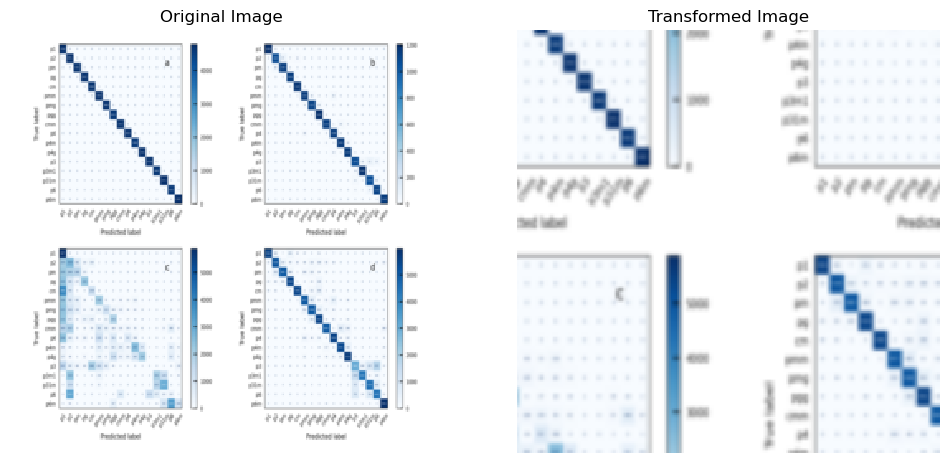

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from PIL import Image
import requests
from io import BytesIO

# Define the STN module
class STN(nn.Module):
    def __init__(self, scaling_factors=(1.5, 1.5)):
        super(STN, self).__init__()
        # This STN will simply use predefined scaling factors
        self.scaling_factors = scaling_factors

    def forward(self, x):
        theta = torch.tensor([[self.scaling_factors[0], 0, 0],
                              [0, self.scaling_factors[1], 0]], dtype=torch.float).unsqueeze(0)
        theta = theta.repeat(x.size(0), 1, 1).to(x.device)
        print(theta)
        grid = F.affine_grid(theta, x.size(), align_corners=False)
        x = F.grid_sample(x, grid, align_corners=False)
        return x

# Load an image from the internet
img = Image.open('../../figures/data_preprocessing/FFT_Radon_transform/Summary_cm-radon.png')

# Transform the image
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor()
])

img_tensor = transform(img).unsqueeze(0)  # Add batch dimension

# Initialize the STN module with arbitrary scaling factors
stn = STN(scaling_factors=(0.5, 0.5))

# Apply the STN
transformed_img_tensor = stn(img_tensor)

# Function to convert a tensor to a PIL image
def tensor_to_pil(tensor):
    tensor = tensor.squeeze(0)  # Remove batch dimension
    unloader = transforms.ToPILImage()
    image = tensor.cpu().clone()
    image = image.squeeze(0)
    image = unloader(image)
    return image

# Visualize the original and transformed images
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(tensor_to_pil(img_tensor), interpolation='none')
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(tensor_to_pil(transformed_img_tensor), interpolation='none')
ax[1].set_title('Transformed Image')
ax[1].axis('off')

plt.show()


In [4]:
import sys
sys.path.append('../../src/benchmark/')
from build_model import resnet50_

import torch
import torch.nn as nn
import torchvision.models as models
from torchvision import transforms
import torch.nn.functional as F

class ScaleAdaptiveModel(nn.Module):
    def __init__(self, pretrained_model):
        super(ScaleAdaptiveModel, self).__init__()
        self.backbone = pretrained_model
        self.fc_classifier = self.backbone.fc
        self.backbone.fc = nn.Identity()  # Assuming you want features not classification
        
        # Initialize the scaling factors to be close to what might be expected if images are larger
        self.scale_factors = nn.Parameter(torch.tensor([1.0, 1.0], dtype=torch.float))

    def stn(self, x):
        theta = torch.diag(self.scale_factors).view(1, 2, 2)
        theta = theta.repeat(x.size(0), 1, 1)  # Repeat for each image in the batch
        print(theta)

        # Extend theta for affine_grid which expects Nx2x3
        affine_mat = torch.zeros(theta.size(0), 2, 3).to(theta.device)
        affine_mat[:, :, :2] = theta
        affine_mat[:, :, 2] = 0  # No translation
        print(affine_mat)

        grid = F.affine_grid(affine_mat, x.size(), align_corners=False)
        x = F.grid_sample(x, grid, align_corners=False)
        return x

    def forward(self, x):
        # Apply scaling transformation
        x = self.stn(x)
        # Pass the transformed input through the backbone
        x = self.backbone(x)
        x = self.fc_classifier(x)
        return x
    
    

In [5]:
# Load your pretrained ResNet50 model
pretrained_resnet50 = resnet50_(3, 17)
pretrained_resnet50 = torch.load('../../epoch-20.pt').module

# Freeze all the parameters in the backbone
for param in pretrained_resnet50.parameters():
    param.requires_grad = False
    
pretrained_resnet50

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [6]:
# Instantiate your model
model = ScaleAdaptiveModel(pretrained_resnet50)

input_tensor = torch.randn((2, 3, 256, 256))  # Example input
output = model(input_tensor)
print(output.shape)  # Output shape from the backbone

# model = torch.nn.DataParallel(model, device_ids=[0,1])
# model

tensor([[[1., 0.],
         [0., 1.]],

        [[1., 0.],
         [0., 1.]]], grad_fn=<RepeatBackward0>)
tensor([[[1., 0., 0.],
         [0., 1., 0.]],

        [[1., 0., 0.],
         [0., 1., 0.]]], grad_fn=<CopySlices>)
torch.Size([2, 17])


### verify without train the first layer

In [ ]:
device = torch.device('cuda:2')
loss_func = nn.CrossEntropyLoss()

for param in model.parameters():
    param.requires_grad = False

In [ ]:
valid(model, loss_func, device, valid_dl, task_label='valid', tracking=False)
valid(model, loss_func, device, atom_dl, task_label='cv_atom', tracking=False)
valid(model, loss_func, device, noise_dl, task_label='cv_noise', tracking=False)

# fine tune the first layer

In [6]:
# Freeze all the parameters in the backbone but the affine transformation layer
for param in model.parameters():
    param.requires_grad = True
    
for param in model.backbone():
    param.requires_grad = False

for param in model.fc_classifier():
    param.requires_grad = False

AttributeError: 'ResNet' object has no attribute 'backbone'

In [7]:
device = torch.device('cuda:0')
lr = 1e-3
start = 0
epochs = 20

loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, epochs=epochs, max_lr=lr, steps_per_epoch=len(train_dl))
history = train_epochs(model, loss_func, optimizer, device, train_dl, valid_dl, cv_dl_list=[atom_dl, noise_dl], cv_name_list=['atom', 'noise'],
                       epochs=epochs, start=start, scheduler=scheduler, model_dir='../../../saved_models/', tracking=True)

Epoch: 1/20


  0%|          | 0/28561 [00:00<?, ?it/s]

  6%|▌         | 1748/28561 [2:31:50<38:49:08,  5.21s/it]


KeyboardInterrupt: 